## Importing Libraries

In [55]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, LSTM, GRU, Dense, TimeDistributed, RepeatVector, Multiply, Permute, Flatten
from keras.callbacks import EarlyStopping


## Data Preprocessing

In [60]:
room1 = pd.read_excel('dataset/data.xlsx', sheet_name='Room1')
room2 = pd.read_excel('dataset/data.xlsx', sheet_name='Room2')

# Lets work with room2 
df = room1.copy()

# Filling missing data point
df = df.interpolate(method='linear')


C:\Users\Tanima\AppData\Local\Temp\ipykernel_13148\943597820.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear')


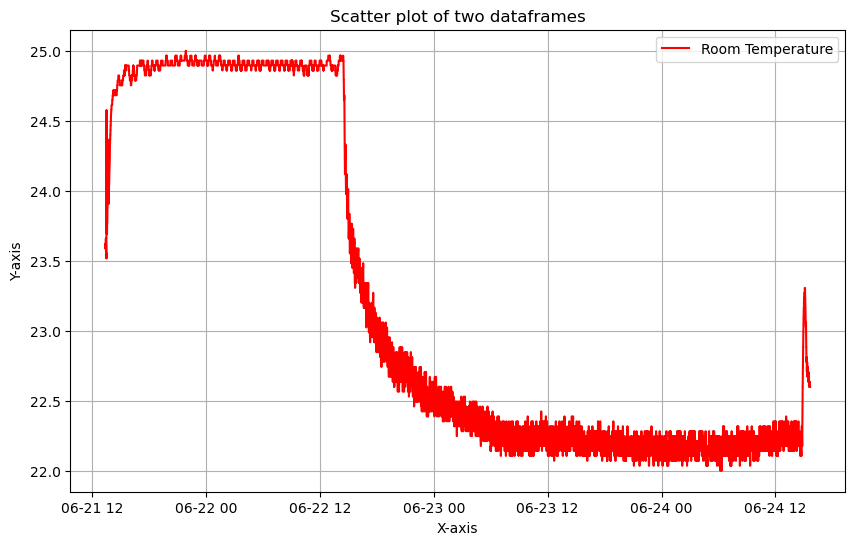

In [61]:
# Data Manipulation
# Normalize room temperatue to range [22, 25]
temp_range = [22, 25]
df['t_room'] = (df['t_room'] - df['t_room'].min()) / (df['t_room'].max() - df['t_room'].min())
df['t_room'] = df['t_room'] * (temp_range[1] - temp_range[0]) + temp_range[0]


# plotting
plt.figure(figsize=(10, 6))

plt.plot(df['timestamp'], df['t_room'], color='red', label = 'Room Temperature')

# Add labels, legend, and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Scatter plot of two dataframes')
plt.grid(True)

# Show plot
plt.show()

In [70]:
# setting setpoint temperature
setpoint = 27
for i in range(df.shape[0]):
    if df.loc[i, 'ac_state'] == 'On':
        setpoint = int(df.loc[i, "t_room"])-1
        df.loc[i, 'setpoint'] = setpoint
    else:
        df.loc[i, 'setpoint'] = setpoint

df['tsp_offset'] = df['t_room'] - df['setpoint']

### Air Conditioner Modelling

In [93]:
class air_conditioner():
    def __init__(self):
        self.ROOM_VOLUME = 50  # m^3
        self.AIR_DENSITY = 1.225  # kg/m^3 (at sea level and 15°C)
        self.SPECIFIC_HEAT_AIR = 1005  # J/kg·K
        self.LATENT_HEAT = 2260 # latent_heat (float): Latent heat of vaporization in J/g.
        self.U = 0.5 # U: Overall heat transfer coefficient (W/m^2·K)
        self.A = 30 # A: Surface area exposed to the outside (m^2)
        self.internal_gain= 500 # internal_gain: Heat from occupants and devices (W)
        self.max_cooling=5300 # max_cooling: Maximum cooling capacity of the AC (W)
        self.min_cooling=500 # min_cooling: Minimum cooling capacity of the AC (W)
        self.cop = 4.25 # COP: Coefficient of performance

    ##  AC temperature modeling given setpoint, indoor and outdoor temperature
    def calculate_heat_gain(self, T_out, T_in):
        """
        Calculate heat gains in the room.
        T_out: Outdoor temperature (°C)
        T_in: Indoor temperature (°C)

        Returns Total heat gain
        """
        Q_conduction = self.U * self.A * (T_out - T_in)
        return Q_conduction + self.internal_gain
    
    def calculate_cooling_capacity(self, T_in, T_set):
        """
        Calculate cooling provided by the AC based on the difference between
        indoor temperature and the setpoint.
        T_in: Indoor temperature (°C)
        T_set: Setpoint temperature (°C)
        
        Returns cooling power (W).
        """
        if T_in > T_set:
            return self.min_cooling + (self.max_cooling - self.min_cooling) * (T_in - T_set) / 10  # Scales linearly up to 10°C difference
        else:
            return 0  # No cooling if the indoor temperature is below the setpoint

    def simulate_temperature(self, T_out, T_set, initial_T_in, minutes):
        """
        Simulate indoor temperature changes over time.
        T_out: Outdoor temperature (°C)
        T_set: Setpoint temperature (°C)
        initial_T_in: Initial indoor temperature (°C)
        minutes: Simulation duration (minutes)
        room_volume: Room volume (m^3)
        Returns array of indoor temperatures over time.
        """
        # Mass of air in the room (kg)
        air_mass = self.ROOM_VOLUME * self.AIR_DENSITY

        # Initial values
        T_in = initial_T_in
        T_in_history = [T_in]

        for _ in range(minutes-1):
            # Calculate heat gain and cooling capacity
            Q_gain = self.calculate_heat_gain(T_out, T_in)
            Q_cooling = self.calculate_cooling_capacity(T_in, T_set)

            # Net heat change
            Q_net = Q_gain - Q_cooling

            # Temperature change (ΔT = Q / (m * c_p))
            delta_T = (Q_net / (air_mass * self.SPECIFIC_HEAT_AIR)) * 60  # 60 seconds per minute

            # Update indoor temperature
            T_in += delta_T
            T_in_history.append(T_in)

        return np.array(T_in_history)
    


    # Air conditioner Energy Calculation Modeling
    def calculate_energy_consumption(self, t_in, t_out, h_in, h_out, setpoint, timestep=60):
        """
        Calculate energy consumption of an inverter AC over a specific timestep. Given,

        t_in: indoor temperature
        t_out: outdoor temperature
        h_in: indoor humidity
        h_out: outdoor humidity
        setpoint: setpoint
        timestep: Energy calculation over timestep time.
        
        """
        # Calculate mass flow rate
        m = self.AIR_DENSITY * self.ROOM_VOLUME / timestep  # Mass flow rate in kg/s

        if t_in > setpoint:
            # Cooling mode
            q_sensible = self.SPECIFIC_HEAT_AIR * m * (t_in - setpoint)
            q_latent = self.LATENT_HEAT * (h_in - h_out) * m * 0.001  # Simplified latent heat in J/kg
            q_total = q_sensible + q_latent
            cop = self.cop * (t_out / (t_out + t_in - setpoint)) if (t_out + t_in - setpoint) != 0 else self.cop

            # Power consumption
            power = q_total / (cop * 3600)  # Convert J/s to kWh

            # Energy consumption for this timestep
            energy = power * (timestep / 3600)  # Convert seconds to hours
        else:
            # No energy consumed if indoor temperature is below or equal to the setpoint
            energy = 0

        return energy
    
    def generate_points(self,
            from_timestep : int, 
            outside_temp : float, 
            init_room_temp : float, 
            setpoint : float, 
            n_datapoints: int = 10
            ):
        
        data = df[from_timestep: from_timestep+n_datapoints].copy()
        room_temperatures = self.simulate_temperature(T_out=outside_temp, 
                                                      T_set=setpoint, 
                                                      initial_T_in=init_room_temp, 
                                                      minutes=n_datapoints)
        
        data["t_room"] = room_temperatures
        data["setpoint"] = setpoint
        data["t_offset"] = data['t_out'] - data['t_room']
        data["tsp_offset"] = data['t_room'] - data['setpoint']
        return data
    

ac = air_conditioner()

In [64]:
# calculating energy
energy_consumption = []
for i in range(df.shape[0]):
    t_in = df.loc[i,'t_room']
    t_out = df.loc[i, 't_out']
    h_in = df.loc[i, 'rh_room']
    h_out = df.loc[i, 'rh_out']
    setpoint = df.loc[i,'setpoint']
    energy = ac.calculate_energy_consumption(t_in=t_in, t_out=t_out, h_in=h_in, h_out=h_out, setpoint=setpoint)
    energy_consumption.append(energy)

df['energy'] = energy_consumption
    

In [65]:
# Extending timestamp to multiple months

data_points_per_day = 6*60
days_per_month = 27
start_date = datetime(2024, 5, 1, 10)  # Start date: May 1, 2024, at 10 AM

# Generate timestamps
timestamps = []
for i in range(len(df)):
    # Calculate day and time
    day_offset = i // data_points_per_day
    time_offset = i % data_points_per_day
    timestamp = start_date + timedelta(days=day_offset, hours=time_offset)
    timestamps.append(timestamp)

# Add timestamps to the DataFrame
df["timestamp"] = timestamps


In [53]:
df

,timestamp,t_room,rh_room,t_out,rh_out,t_offset,office_hour,ac_state,rh_offset,setpoint,energy
0,2024-05-01 10:00:00,22.647059,54.0,32.68,70,4.98,No,On,16.0,21.0,0.001891
1,2024-05-01 11:00:00,22.647059,54.0,32.68,70,4.98,No,On,16.0,21.0,0.001891
2,2024-05-01 12:00:00,22.705882,54.0,32.68,70,4.88,No,On,16.0,21.0,0.001964
3,2024-05-01 13:00:00,22.705882,53.0,32.68,70,4.88,No,On,17.0,21.0,0.001961
4,2024-05-01 14:00:00,22.647059,54.0,32.68,70,4.98,No,On,16.0,21.0,0.001891
...,...,...,...,...,...,...,...,...,...,...,...
22961,2024-07-15 03:00:00,21.000000,46.0,36.39,66,11.49,Yes,On,20.0,20.0,0.001097
22962,2024-07-15 04:00:00,21.000000,46.0,38.95,66,14.05,Yes,On,20.0,20.0,0.001095
22963,2024-07-15 05:00:00,21.000000,46.0,38.95,66,14.05,Yes,On,20.0,20.0,0.001095
22964,2024-07-15 06:00:00,21.000000,46.0,38.95,66,14.05,Yes,On,20.0,20.0,0.001095


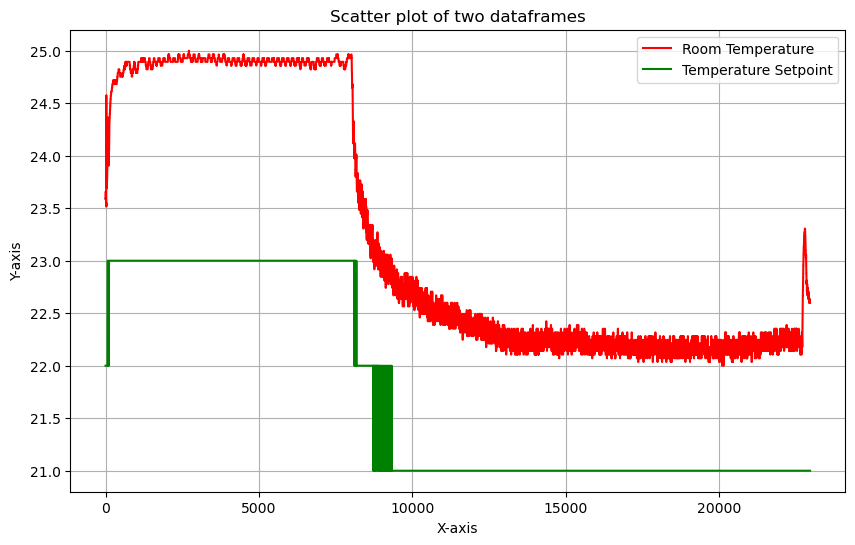

In [66]:
# plotting
plt.figure(figsize=(10, 6))

# plt.plot(df['energy'], color='blue', label='energy curve')
plt.plot(df['t_room'], color='red', label = 'Room Temperature')
plt.plot(df['setpoint'], color='green', label = "Temperature Setpoint")

# Add labels, legend, and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Scatter plot of two dataframes')
plt.grid(True)

# Show plot
plt.show()


In [74]:
## selecting features and finding correlation
# features = ['t_room', 'rh_room', 't_out','rh_out','t_offset','rh_offset','setpoint', 'energy']
features = ['t_offset', 'rh_offset', 'tsp_offset', 'energy']

In [75]:
df[features].corr()

,t_offset,rh_offset,tsp_offset,energy
t_offset,1.000000,0.321782,-0.767225,-0.777731
rh_offset,0.321782,1.000000,-0.394569,-0.451214
tsp_offset,-0.767225,-0.394569,1.000000,0.997847
energy,-0.777731,-0.451214,0.997847,1.000000


In [11]:
data_for_correlation = df.copy()
data_for_correlation['t_sp_offset'] = data_for_correlation['t_room']-data_for_correlation['setpoint']
data_for_correlation[features + ['t_sp_offset']].corr()

,t_room,rh_room,t_out,rh_out,t_offset,rh_offset,setpoint,energy,t_sp_offset
t_room,1.000000,0.958451,-0.365917,0.516561,-0.866301,-0.547582,0.991324,0.927838,0.925287
rh_room,0.958451,1.000000,-0.409064,0.482760,-0.861627,-0.621584,0.928688,0.953577,0.948728
t_out,-0.365917,-0.409064,1.000000,-0.575556,0.781873,-0.083916,-0.345743,-0.393270,-0.387629
rh_out,0.516561,0.482760,-0.575556,1.000000,-0.654970,0.385943,0.539113,0.395722,0.399962
t_offset,-0.866301,-0.861627,0.781873,-0.654970,1.000000,0.321782,-0.849661,-0.832642,-0.827906
rh_offset,-0.547582,-0.621584,-0.083916,0.385943,0.321782,1.000000,-0.496056,-0.650536,-0.641634
setpoint,0.991324,0.928688,-0.345743,0.539113,-0.849661,-0.496056,1.000000,0.870873,0.867407
energy,0.927838,0.953577,-0.393270,0.395722,-0.832642,-0.650536,0.870873,1.000000,0.999654
t_sp_offset,0.925287,0.948728,-0.387629,0.399962,-0.827906,-0.641634,0.867407,0.999654,1.000000


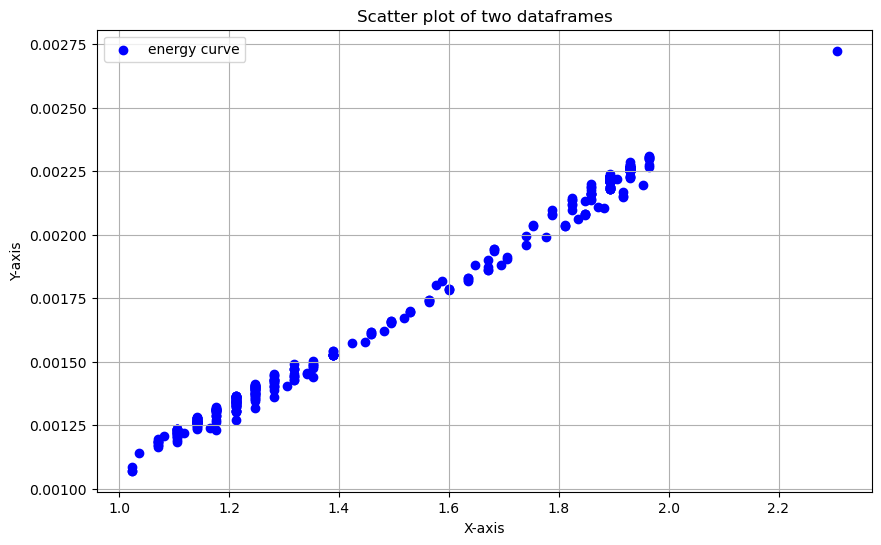

In [108]:
## Energy Vs t_offset
# plotting
plt.figure(figsize=(10, 6))

plt.scatter(df['tsp_offset'][::60], df['energy'][::60], color='blue', label='energy curve')
# plt.scatter(df['rh_offset'][::60], df['energy'][::60], color='blue', label='energy curve')
# plt.scatter(df['t_offset'][::60], df['energy'][::60], color='red', label = 'Temperature Difference')

# Add labels, legend, and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.title('Scatter plot of two dataframes')
plt.grid(True)

# Show plot
plt.show()

### Preping Data For Model Training

In [76]:
X = df[features].astype('float')

y = df['energy'].astype('float')
predicted_label = "energy"

X = X.values
y = y.values

In [77]:
# Normalize data
test_split = 0.7

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaler_X.fit(X[:int(len(X)*test_split)])
scaler_y.fit(y.reshape(-1, 1)[:int(len(y)*test_split)])

X = scaler_X.transform(X)
y = scaler_y.transform(y.reshape(-1, 1))

In [78]:
# Reshape for LSTM input: [samples, timesteps, features]
sequence_length = 10  # Example: Use the past 24 hours
X_seq, y_seq = [], []

for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i + sequence_length])
    y_seq.append(y[i + sequence_length])

X_seq, y_seq = np.array(X_seq), np.array(y_seq)


In [79]:
# Train-test split
test_split = 0.7
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=(1-test_split), shuffle=False)

## Model

In [80]:
# LSTM model
from model_definition import *
model_name = "lstm_attention"
input_shape = (sequence_length, X.shape[1])

model_map = {
    "cnn": build_cnn_model,
    "lstm": build_lstm_model,
    "gru": build_gru_model,
    "bilstm": build_bilstm_model,
    "bigru": build_bigru_model,
    "cnn_lstm": build_cnn_lstm_model,
    "cnn_gru": build_cnn_gru_model,
    "lstm_attention": build_lstm_attention_model,
    "gru_attention": build_gru_attention_model
}

model = model_map[model_name](input_shape) 

In [16]:
# Loading model
checkpoint_path = "checkpoints/"+ model_name + "_" + predicted_label + "_" + str(sequence_length) + "_v2.h5"
# checkpoint_path = "checkpoints/best_model.h5"
model = tf.keras.models.load_model(checkpoint_path)

In [81]:
# Train the model
early_stopping = EarlyStopping(
    monitor='val_loss',   # Metric to monitor
    patience=10,           # Number of epochs with no improvement to wait
    mode='min',           # 'min' because we want val_loss to decrease
    restore_best_weights=True  # Restore the best weights
)

history = model.fit(X_train, 
                    y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_split=0.2, 
                    shuffle=True, 
                    callbacks=[early_stopping]
                    )
# Save the model
checkpoint_path = "checkpoints/"+ model_name + "_" + predicted_label + "_" + str(sequence_length) + "_v2.h5"
model.save(checkpoint_path)


Epoch 1/50
402/402 [==============================] - 5s 9ms/step - loss: 0.0134 - mae: 0.0612 - val_loss: 0.0011 - val_mae: 0.0285
Epoch 2/50
402/402 [==============================] - 3s 8ms/step - loss: 0.0032 - mae: 0.0265 - val_loss: 0.0021 - val_mae: 0.0404
Epoch 3/50
402/402 [==============================] - 3s 8ms/step - loss: 0.0029 - mae: 0.0249 - val_loss: 0.0011 - val_mae: 0.0289
Epoch 4/50
402/402 [==============================] - 4s 9ms/step - loss: 0.0027 - mae: 0.0235 - val_loss: 7.2154e-04 - val_mae: 0.0233
Epoch 5/50
402/402 [==============================] - 4s 9ms/step - loss: 0.0026 - mae: 0.0225 - val_loss: 8.4031e-04 - val_mae: 0.0252
Epoch 6/50
402/402 [==============================] - 3s 8ms/step - loss: 0.0024 - mae: 0.0212 - val_loss: 8.9282e-04 - val_mae: 0.0260
Epoch 7/50
402/402 [==============================] - 3s 9ms/step - loss: 0.0022 - mae: 0.0200 - val_loss: 0.0013 - val_mae: 0.0315
Epoch 8/50
402/402 [==============================] - 3s 8ms/ste

In [14]:
# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")

441/441 [==============================] - 5s 9ms/step - loss: 1.5427e-04 - mae: 0.0091
Test Loss: 0.00015427370090037584, Test MAE: 0.009134303778409958


## Plotting

718/718 [==============================] - 3s 3ms/step


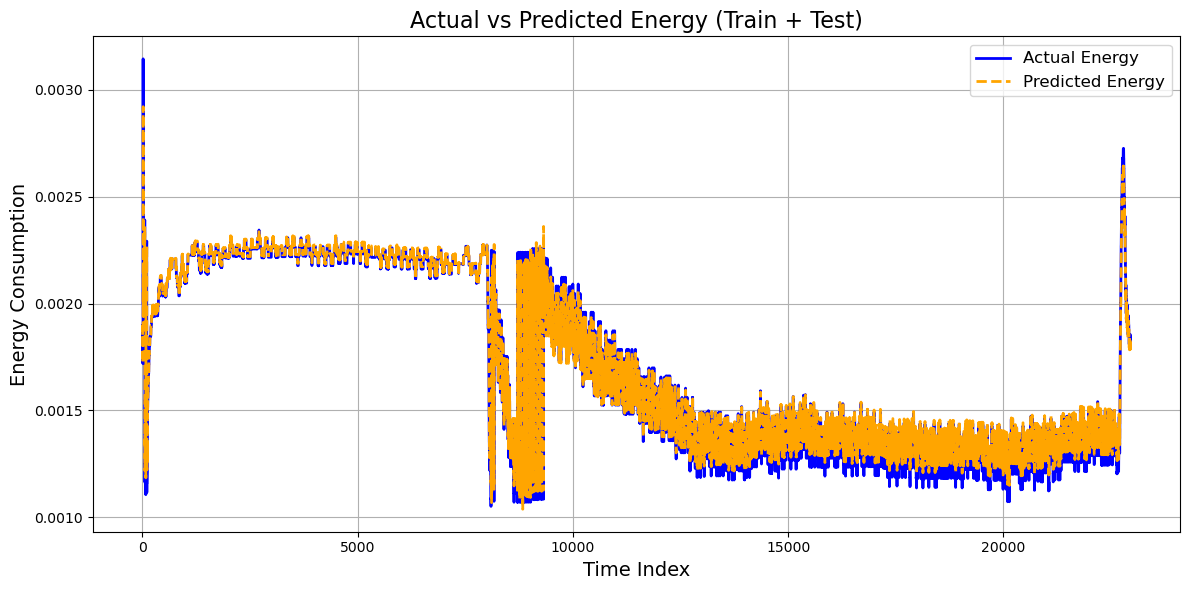

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Predict on both train and test data
predicted = model.predict(X_seq)
predicted = scaler_y.inverse_transform(predicted)
actual = scaler_y.inverse_transform(y_seq)

# Create a time index for plotting (or use actual timestamps if available)
time_index = np.arange(len(actual))

# Plot the combined actual and predicted energy values
plt.figure(figsize=(12, 6))
plt.plot(time_index, actual, label='Actual Energy', color='blue', linewidth=2)
plt.plot(time_index, predicted, label='Predicted Energy', color='orange', linestyle='--', linewidth=2)

# Add labels, title, and legend
plt.title('Actual vs Predicted Energy (Train + Test)', fontsize=16)
plt.xlabel('Time Index', fontsize=14)  # Replace with actual time unit if available
plt.ylabel('Energy Consumption', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [17]:
# prediction on full dataset
predicted = model.predict(X_seq)
predicted = scaler_y.inverse_transform(predicted)
actual = scaler_y.inverse_transform(y_seq)

predicted = predicted.squeeze()
actual = actual.squeeze()

pred_dataset = pd.DataFrame()
pred_dataset['actual'] = actual
pred_dataset['predicted'] = predicted

output_file_path = "output/"+ model_name + "_" + predicted_label + "_" + str(sequence_length) + ".csv"
pred_dataset.to_csv(output_file_path)


1102/1102 [==============================] - 7s 7ms/step


In [37]:
# prediction on test dataset
predicted = model.predict(X_test)
predicted = scaler_y.inverse_transform(predicted)
actual = scaler_y.inverse_transform(y_test)

# Calculate MSE
mse = np.mean((predicted - actual) ** 2)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate NRMSE (using the range of actual values for normalization)
nrmse = rmse / (actual.max() - actual.min())

# Calculate MAE
mae = np.mean(np.abs(predicted - actual))

# Calculate MAPE
mape = np.mean(np.abs((actual - predicted) / actual)) * 100


# Print the results
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"NRMSE: {nrmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}%")

216/216 [==============================] - 1s 4ms/step
MSE: 0.0000
RMSE: 0.0002
NRMSE: 0.0848
MAE: 0.0001
MAPE: 6.9438%


## Thermal Comfort Analysis

In [84]:
from pythermalcomfort.models import pmv_ppd
from pythermalcomfort.utilities import v_relative, clo_dynamic, met_typical_tasks, clo_individual_garments

# input variables
tdb = 28  # dry bulb air temperature, [$^{\circ}$C]
tr = 25  # mean radiant temperature, [$^{\circ}$C]
v = 0.1  # average air speed, [m/s]
rh = 70  # relative humidity, [%]
activity = "Typing"  # participant's activity description
garments = ["Sweatpants", "T-shirt", "Shoes or sandals"]

met = met_typical_tasks[activity]  # activity met, [met]

icl = sum(
    [clo_individual_garments[item] for item in garments]
)  # calculate total clothing insulation

# calculate the relative air velocity
vr = v_relative(v=v, met=met)
# calculate the dynamic clothing insulation
clo = clo_dynamic(clo=icl, met=met)

# calculate PMV in accordance with the ASHRAE 55 2020
results = pmv_ppd(tdb=tdb, tr=tr, vr=vr, rh=rh, met=met, clo=clo, standard="ASHRAE")

# print the results
print(results)

# print PMV value
print(f"pmv={results['pmv']}, ppd={results['ppd']}%")

{'pmv': 0.28, 'ppd': 6.6}
pmv=0.28, ppd=6.6%


## Energy Saving Prediction

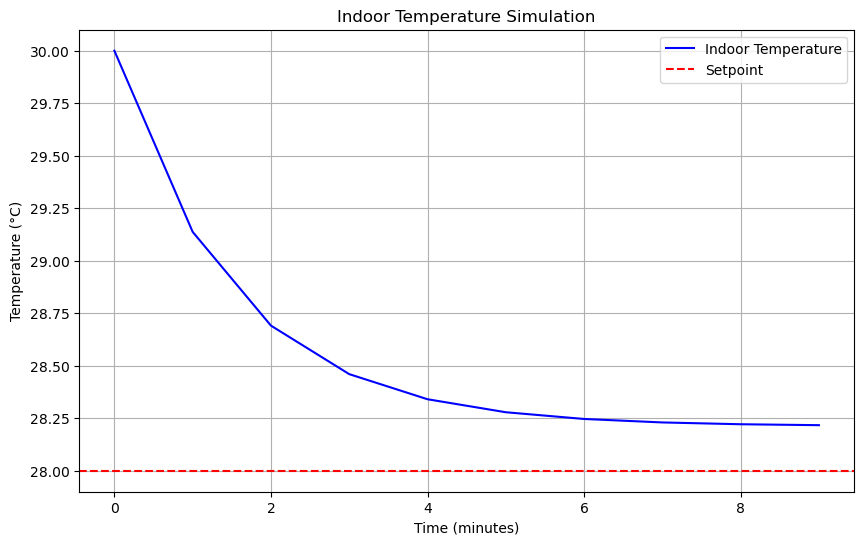

[30.         29.13737435 28.6909531  28.45992364 28.34036255 28.27848796
 28.24646697 28.22989564 28.22131973 28.21688158]


In [85]:
## Example of how air conditioner changes room temperature given a specific setpoint 

# Simulation parameters
T_out = 35  # Outdoor temperature (°C)
T_set = 28  # Setpoint temperature (°C)
initial_T_in = 30  # Initial indoor temperature (°C)
minutes = 10  # Simulation duration (minutes)

# Run simulation
indoor_temperatures = ac.simulate_temperature(T_out, T_set, initial_T_in, minutes)

# Plot results
time = np.arange(minutes)  # Time steps (0 to minutes)
plt.figure(figsize=(10, 6))
plt.plot(time, indoor_temperatures, label="Indoor Temperature", color="blue")
plt.axhline(y=T_set, color="red", linestyle="--", label="Setpoint")
plt.title("Indoor Temperature Simulation")
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()
plt.show()
print(indoor_temperatures)

In [86]:
def predict_energy(X_, y_):
    # Normalizing
    X_ = scaler_X.transform(X_)
    y_ = scaler_y.transform(y_)

    # Predicting
    X_ = np.expand_dims(X_, 0)
    # E_pred = model.predict(X_)
    E_pred = model(X_).numpy()
    
    # Inverse Normalization
    E_pred = scaler_y.inverse_transform(E_pred).squeeze()
    E_real = scaler_y.inverse_transform(y_).squeeze()

    return E_pred, E_real

In [ ]:
# Example of generating new datapoint by setting a setpoint

# df_sys = df[:sequence_length + 1].copy()
# timestep = 10
# room_temperature = df_sys.loc[timestep]['t_room']
# outside_temperature = df_sys.loc[timestep]['t_out']
# data = ac.generate_points(timestep, outside_temperature, room_temperature, 27.0)
# # df_sys = pd.concat([df_sys, data], axis=0)
# df_sys = pd.concat([df_sys, data]).groupby(level=0).last()
# df_sys

In [94]:
# input variables
tr = 25  # mean radiant temperature, [$^{\circ}$C]
v = 0.1  # average air speed, [m/s]
activity = "Typing"  # participant's activity description
met = met_typical_tasks[activity]  # activity met, [met]
vr = v_relative(v=v, met=met) # calculate the relative air velocity

# calculate total clothing insulation
garments = ["Sweatpants", "T-shirt", "Shoes or sandals"]
icl = sum(
    [clo_individual_garments[item] for item in garments]
)
clo = clo_dynamic(clo=icl, met=met)

min_pmv = -0.2
max_pmv = 0.2

# initializing dataframe for storing 
df_sys = df[:sequence_length + 1].copy()

for i in range(sequence_length, len(df)-20):
    
    # checking if temperature is within thermal comfort   
    room_temperature = df_sys.loc[i]['t_room']
    outside_temperature = df_sys.loc[i]['t_out']
    room_humidity = df_sys.loc[i]['rh_room']
    outside_humity = df_sys.loc[i]['rh_out']

    results = pmv_ppd(tdb=room_temperature, tr=tr, vr=vr, rh=room_humidity, met=met, clo=clo, standard="ASHRAE", limit_inputs=False )
    pmv = results['pmv']
    print('timestep : ',i, ' PMV : ',pmv)

    
    # if room temperature is within comfort zone, Select setpoint that achieves maximum acceptable pmv score
    setpoint = room_temperature
    if min_pmv <= pmv <= max_pmv:
        while min_pmv <= pmv <= max_pmv:
            setpoint = setpoint + 1
            results = pmv_ppd(tdb=setpoint, tr=tr, vr=vr, rh=room_humidity, met=met, clo=clo, standard="ASHRAE", limit_inputs=False)
            pmv = results['pmv']
        
        setpoint = setpoint-1
    
    # if room temperature is outside of comfort zone
    else:
        # if pmv is positive, reduce temperature for comfort
        if pmv > 0:
            while pmv >= max_pmv:
                setpoint = setpoint -1
                results = pmv_ppd(tdb=setpoint, tr=tr, vr=vr, rh=room_humidity, met=met, clo=clo, standard="ASHRAE", limit_inputs= False)
                pmv = results['pmv']
        
        # if pmv is negative, increase temperature for comfort
        else:
            while pmv <= min_pmv:
                setpoint = setpoint + 1
                results = pmv_ppd(tdb=setpoint, tr=tr, vr=vr, rh=room_humidity, met=met, clo=clo, standard="ASHRAE", limit_inputs= False)
                pmv = results['pmv']

    setpoint = np.round(setpoint)    
    print(setpoint)

    # Use the setpoint to generate some datapoints
    # Ideally these datapoints should come from IoT sensors
    if (i == df_sys.index[-1]) or ((pmv <=min_pmv) and (pmv >= max_pmv)):
        print('Simulating room temperature data for air-conditioner')
        data = ac.generate_points(from_timestep=i,
                           outside_temp=outside_temperature,
                           init_room_temp= room_temperature,
                           setpoint=setpoint,
                           n_datapoints=10)
        df_sys = pd.concat([df_sys, data]).groupby(level=0).last()

    # Taking past 'sequence length' timesteps as input to predict current energy
    X_ = df_sys.loc[i-sequence_length:i-1, features].values
    y_ = df_sys.loc[i]['energy'].reshape(-1, 1)
    
    # Predicting predicted and real current value in Amps
    E_pred, _ = predict_energy(X_, y_)
    
    # Store the new prediction to the dataframe and repeat
    df_sys.loc[i, 'energy'] = E_pred
    

timestep :  10  PMV :  -0.78
27.0
Simulating room temperature data for air-conditioner
timestep :  11  PMV :  -0.66
27.0
timestep :  12  PMV :  -0.54
27.0
timestep :  13  PMV :  -0.42
27.0
timestep :  14  PMV :  -0.3
27.0
timestep :  15  PMV :  -0.19
28.0
timestep :  16  PMV :  -0.07
28.0
timestep :  17  PMV :  -0.07
28.0
timestep :  18  PMV :  -0.08
28.0
timestep :  19  PMV :  -0.08
28.0
Simulating room temperature data for air-conditioner
timestep :  20  PMV :  0.04
28.0
timestep :  21  PMV :  0.15
28.0
timestep :  22  PMV :  0.14
28.0
timestep :  23  PMV :  0.13
28.0
timestep :  24  PMV :  0.13
28.0
timestep :  25  PMV :  0.37
27.0
timestep :  26  PMV :  0.44
26.0
timestep :  27  PMV :  0.45
26.0
timestep :  28  PMV :  0.34
27.0
Simulating room temperature data for air-conditioner
timestep :  29  PMV :  0.19
28.0
timestep :  30  PMV :  0.03
27.0
timestep :  31  PMV :  0.03
27.0
timestep :  32  PMV :  0.01
27.0
timestep :  33  PMV :  -0.02
28.0
timestep :  34  PMV :  -0.02
28.0
times

In [97]:
df_sys.to_csv('output/simulated_dataset.csv')

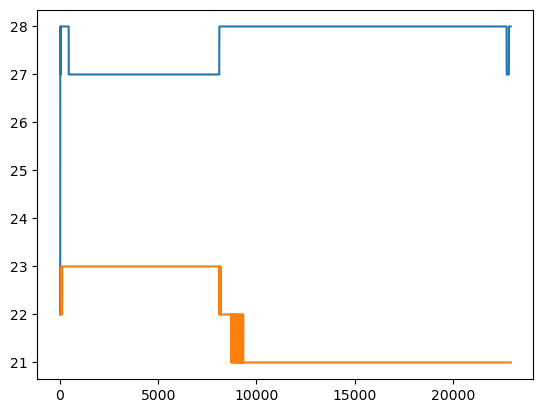

In [95]:
plt.plot(df_sys['setpoint'])
plt.plot(df['setpoint'])

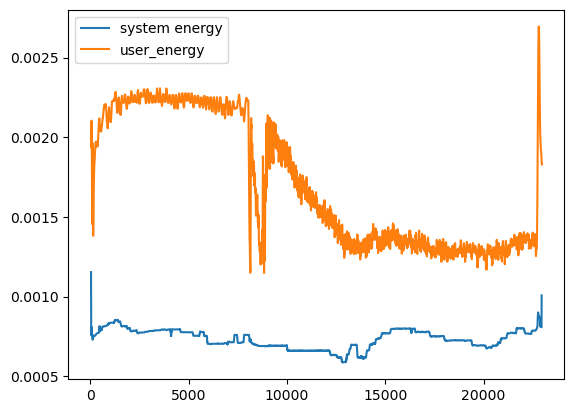

In [96]:
plt.plot(df_sys['energy'].rolling(30).mean(), label = "system energy")
plt.plot(df['energy'].rolling(30).mean(), label = "user_energy")
plt.legend()
plt.show()